# 02 — The Chicago Hedonic (Post 1.1)

**Guiding question:** what are you paying for — the house, or where it sits?

Steps 1–5 live here as one narrative. `src/` holds the reusable machinery;
this notebook is the story.

## Step 1 — One feature first
Regress `log(sale price)` on a single predictor (building size) and read *every*
number in the output by hand, before piling on predictors. Goal: fluency, not findings.

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from chicago_housing import config as C
from chicago_housing.data.load import load_training_data
from chicago_housing.data import clean
from chicago_housing.features import assemble
from chicago_housing.models import inference

# rows then columns (the separation we built)
df       = load_training_data(columns=C.analysis_columns())
sample   = clean.build_analytic_sample(df)     # scope + validity + log target
model_df = assemble.build_features(sample)     # + dist_to_loop_ft, school flag
model_df.shape

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
scope_filter:         413,289 ->   33,106 rows
drop_non_market: 33,106 -> 30,693
  always (PTAX/family):   1,747
  below $10,000 floor:  0
  entity + nominal/low:   670
  land-trust/title kept (market price): 1,247
analytic sample:                30,693 rows


(30693, 43)

In [3]:
# Run the OLS with a single predictor: square footage
res1 = inference.fit_ols(model_df, C.TARGET, ["char_bldg_sf"])
print(res1.summary())

                            OLS Regression Results                            
Dep. Variable:         log_sale_price   R-squared:                       0.410
Model:                            OLS   Adj. R-squared:                  0.410
Method:                 Least Squares   F-statistic:                 2.131e+04
Date:                Sat, 04 Jul 2026   Prob (F-statistic):               0.00
Time:                        13:01:19   Log-Likelihood:                -29383.
No. Observations:               30691   AIC:                         5.877e+04
Df Residuals:                   30689   BIC:                         5.879e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           11.4926      0.009   1331.103   

### Reading the summary, field by field

Fill these in from the output above — the point is to map each ISL quantity to a real number:

- **coef (`char_bldg_sf`)** — β̂₁: change in *log* price per +1 sqft. Small by construction (1 sqft is tiny). Interpret per 100 sqft in the next cell. Change in 100 sq.ft changes the log price by 0.08 units
- **coef (`const`)** — β̂₀: fitted log-price at 0 sqft. Not meaningful on its own (extrapolation), just anchors the line. At zero square feet, log price is 11.5 - this doesn't mean much, which is why typically distributions are centered around the mean.
- **std err** — SE(β̂₁): the slope's uncertainty. This indicates the variation in residuals
- **t** — β̂₁ / SE. How many SEs the slope sits from zero.
- **P>|t|** — p-value for H₀: β₁ = 0.
- **[0.025 0.975]** — 95% CI ≈ β̂₁ ± ~2·SE: slopes compatible with the data.
- **R-squared** — share of log-price variance explained by size alone.
- **F-statistic** — joint significance (here, one predictor, so F = t² — verified below).
- **No. Observations** — N.

> **The big-N caveat (write this into the post):** with ~30k rows the SE is minuscule, t is enormous, p ≈ 0. "Statistically significant" is therefore trivially true and says nothing interesting. The real story is the **effect size** and **R²** — how much size actually moves price, and how much it leaves unexplained.

In [4]:
tidy  = inference.tidy_coefficients(res1)
stats = inference.fit_summary_stats(res1)
display(tidy)
display(stats.to_frame("value"))

,term,coef,std_err,t,p_value,ci_low,ci_high
0,const,11.492573,0.008634,1331.102730,0.0,11.475650,11.509496
1,char_bldg_sf,0.000785,0.000005,145.987277,0.0,0.000775,0.000796


,value
n_obs,30691.000000
r_squared,0.409842
adj_r_squared,0.409822
rse,0.630325
f_stat,21312.285063
f_pvalue,0.000000


In [5]:
beta = res1.params["char_bldg_sf"]

# Y is log(price), so +100 sqft multiplies price by exp(100*beta)
pct_per_100sqft = (np.exp(100 * beta) - 1) * 100
print(f"+100 sqft  ->  {pct_per_100sqft:.2f}% price change")

# satisfying identity: in simple regression, F == t^2
t = res1.tvalues["char_bldg_sf"]
print(f"F = {res1.fvalue:.2f} ;  t^2 = {t**2:.2f} ;  equal? {np.isclose(res1.fvalue, t**2)}")

# RSE is in log units -> roughly a % spread of the typical residual
print(f"RSE (log units) ≈ {np.sqrt(res1.scale):.3f}  (~{np.sqrt(res1.scale)*100:.0f}% typical miss)")

+100 sqft  ->  8.17% price change
F = 21312.29 ;  t^2 = 21312.29 ;  equal? True
RSE (log units) ≈ 0.630  (~63% typical miss)


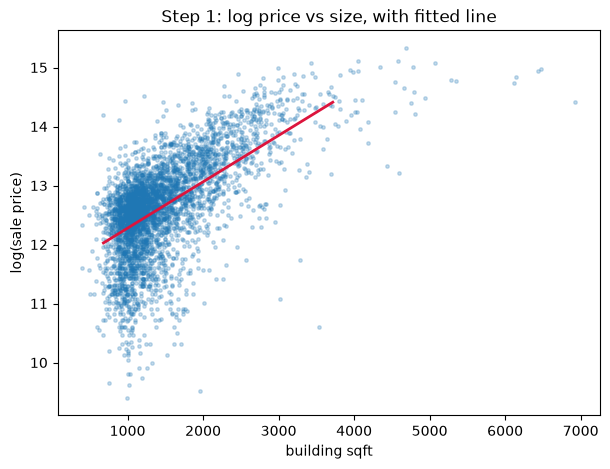

In [6]:
s = model_df.sample(min(4000, len(model_df)), random_state=0)  # readable scatter
plt.figure(figsize=(7, 5))
plt.scatter(s["char_bldg_sf"], s[C.TARGET], s=6, alpha=0.25)
xs = np.linspace(s["char_bldg_sf"].quantile(.01), s["char_bldg_sf"].quantile(.99), 100)
plt.plot(xs, res1.params["const"] + beta * xs, color="crimson", lw=2)
plt.xlabel("building sqft"); plt.ylabel("log(sale price)")
plt.title("Step 1: log price vs size, with fitted line")
plt.show()

### What to notice (and park for later)

- The line fits, but the cloud **fans out** — residual spread grows with size. That's heteroskedasticity; we don't touch it yet (Step 5 formalizes it), but note it.
- A straight line on raw sqft imposes "each sqft adds a constant *percent*." Plausible? The curvature you may see here motivates **Step 4**, where we swap to `log(sqft)` and the slope becomes an **elasticity** (% price per % size) — the canonical hedonic form. That before/after is Substack material.

**Next — Step 2:** all of Block A together (multiple regression), the overall F-test, and how much of price the house alone explains.